In [3]:
import rasterio
from rasterio.plot import plotting_extent
import matplotlib.pyplot as plt
from osgeo import gdal
gdal.UseExceptions()
import importlib
import sys
import geopandas as gpd

sys.path.append('../scripts')
import model_comparison_functions

importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data

In [ ]:
task1_raw_data = get_raw_data("C:/Users/13038/Desktop/SIRO/Model_Outputs/dates/dates", 1)
task2_raw_data = get_raw_data("C:/Users/13038/Desktop/SIRO/Model_Outputs/dates/dates", 2)
task1 = process_all_dates("C:/Users/13038/Desktop/SIRO/Model_Outputs/dates/dates", 1)
task2 = process_all_dates("C:/Users/13038/Desktop/SIRO/Model_Outputs/dates/dates", 2)

In [4]:

##Be sure to update these file paths. These shapefiles are in the date template
mcs_shp = gpd.read_file(
    "C:/Users/13038/Desktop/SIRO/shapes/MCS_outline.shp"
)

basin_shp = gpd.read_file(
    "C:/Users/13038/Desktop/SIRO/shapes/basin_outline.shp"
)

C:\Users\13038\miniconda3\envs\siro_env\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


In [7]:
date = '20230405'

basin_task1 = task1[date]['basin_clip']
HMSEB = basin_task1['HMS-EB']
HMSTI = basin_task1['HMS-TI']
iSnobal = basin_task1['iSnobal']
SnowModel = basin_task1['SnowModel']

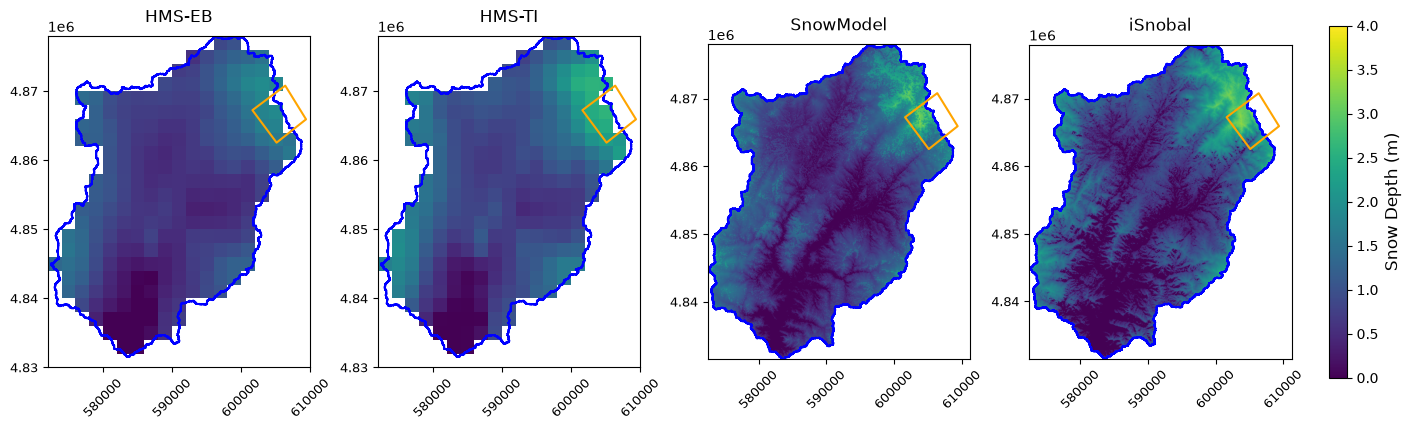

In [14]:
raster_list = {'HMS-EB': HMSEB, 'HMS-TI': HMSTI, 'SnowModel': SnowModel, 'iSnobal': iSnobal}

fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 4.5),
    constrained_layout=True
)

axes = axes.flatten()

for i, (model, raster) in enumerate(raster_list.items()):
    with rasterio.open(raster) as src:
        data = src.read(1, masked=True)
        extent = plotting_extent(src)

    im = axes[i].imshow(
        data,
        cmap="viridis",
        extent=extent,
        vmin=0,
        vmax=4.0
    )

    # Plot boundaries
    basin_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="blue",
        linewidth=1.5
    )

    mcs_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="orange",
        linewidth=1.5
    )

    axes[i].set_title(
        model,
        fontsize=12,
        color="black",
        pad=10
    )

    axes[i].tick_params(
        axis="x",
        rotation=45,
        labelsize=9
    )

    axes[i].tick_params(
        axis="y",
        labelsize=9
    )

    axes[i].grid(False)
    axes[i].set_aspect("equal")

# Add shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    pad=0.02
)

cbar.set_label(
    "Snow Depth (m)",
    fontsize=12
)

cbar.ax.tick_params(labelsize=10)

plt.savefig(
    "C:/Users/13038/Desktop/SIRO/docs/docs/figs/1row_basin.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

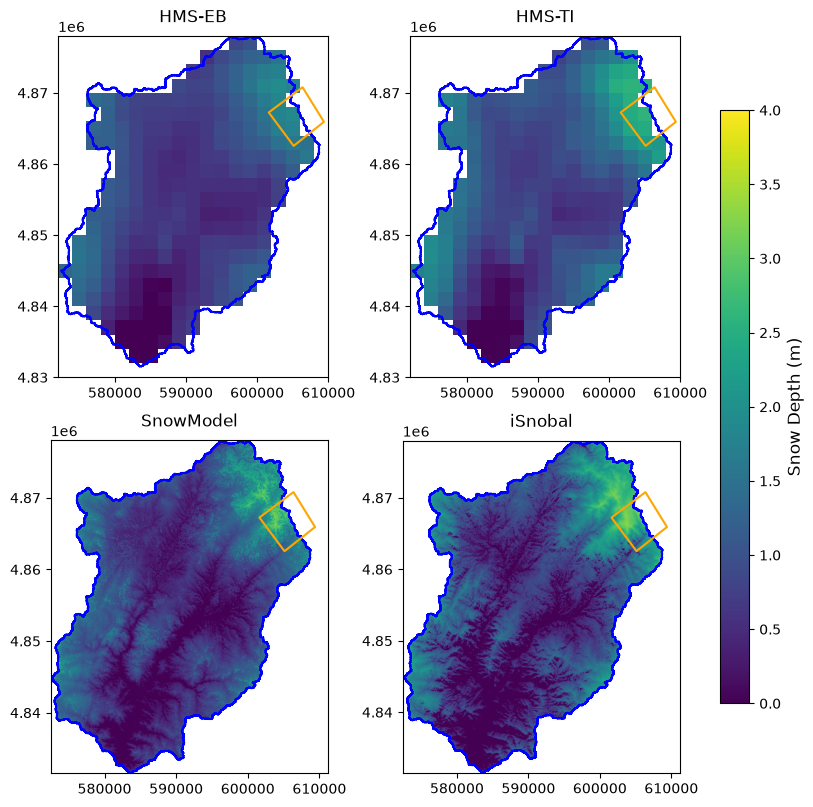

In [16]:

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 8),
    constrained_layout=True
)

axes = axes.flatten()

for i, (model, raster) in enumerate(raster_list.items()):
    with rasterio.open(raster) as src:
        data = src.read(1, masked=True)
        extent = plotting_extent(src)

    im = axes[i].imshow(
        data,
        cmap="viridis",
        extent=extent,
        vmin=0,
        vmax=4.0
    )

    # Plot outlines
    basin_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="blue",
        linewidth=1.5
    )

    mcs_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="orange",
        linewidth=1.5
    )

    axes[i].grid(False)
    axes[i].set_aspect("equal")

# Set titles AFTER all plotting
for i, (model, raster) in enumerate(raster_list.items()):
    axes[i].set_title(
        model,
        fontsize=12,
        pad=10
    )

# Add colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    pad=0.02
)

cbar.set_label(
    "Snow Depth (m)",
    fontsize=12
)

plt.savefig(
    "C:/Users/13038/Desktop/SIRO/docs/docs/figs/2row_basin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

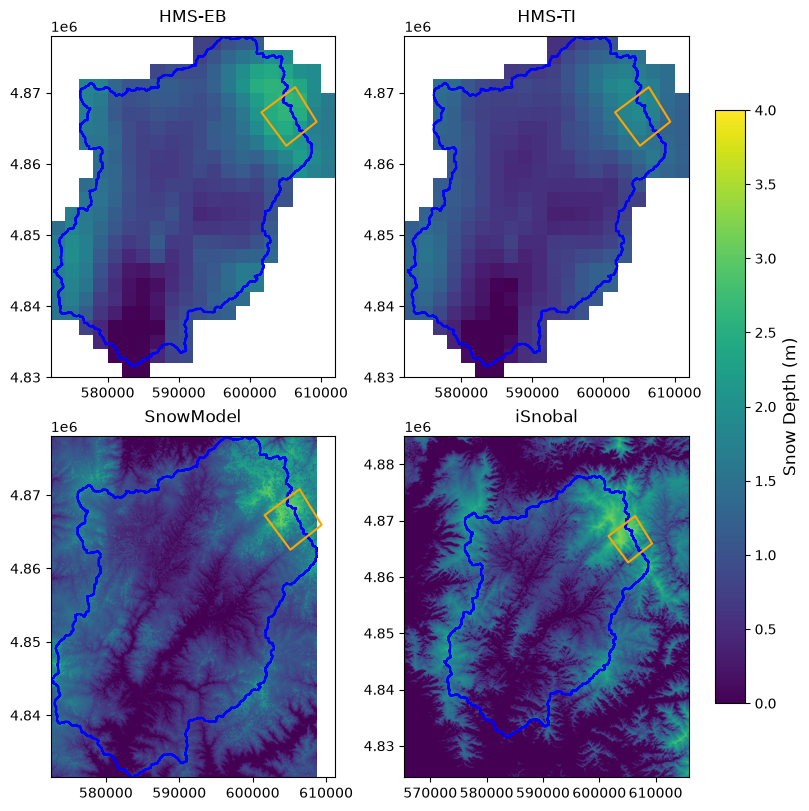

In [19]:
raw_rasters = task1_raw_data['20230405']


fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 8),
    constrained_layout=True
)

axes = axes.flatten()

for i, (model, raster) in enumerate(raw_rasters.items()):
    with rasterio.open(raster) as src:
        data = src.read(1, masked=True)
        extent = plotting_extent(src)

    im = axes[i].imshow(
        data,
        cmap="viridis",
        extent=extent,
        vmin=0,
        vmax=4.0
    )

    # Plot outlines
    basin_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="blue",
        linewidth=1.5
    )

    mcs_shp.plot(
        ax=axes[i],
        facecolor="none",
        edgecolor="orange",
        linewidth=1.5
    )

    axes[i].grid(False)
    axes[i].set_aspect("equal")

# Set titles AFTER all plotting
for i, (model, raster) in enumerate(raster_list.items()):
    axes[i].set_title(
        model,
        fontsize=12,
        pad=10
    )

# Add colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    pad=0.02
)

cbar.set_label(
    "Snow Depth (m)",
    fontsize=12
)

plt.savefig(
    "C:/Users/13038/Desktop/SIRO/docs/docs/figs/full_domain_figure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()